# Semantic Search Visualized

**Goal:** Build an intuition for how semantic search works by seeing it in action. By the end of this notebook, you'll understand embeddings, vector similarity, and why semantic search finds results that keyword search misses.

**No API keys required** — this notebook uses open-source models that run locally.

---

## What You'll Learn

1. How text is converted into numerical vectors (embeddings)
2. Why similar concepts produce similar vectors
3. How vector similarity search works (cosine similarity)
4. The difference between keyword search and semantic search
5. How to visualize high-dimensional embeddings in 2D

## Setup

Install dependencies if you haven't already:

In [2]:
# Uncomment and run if you need to install dependencies
!pip install sentence-transformers scikit-learn matplotlib numpy plotly

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 35.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 31.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 42.5 MB/s eta

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("Dependencies loaded successfully!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies loaded successfully!


## Step 1: Load an Embedding Model

An **embedding model** converts text into vectors (arrays of numbers) that capture semantic meaning.
We'll use `all-MiniLM-L6-v2` — a lightweight, open-source model that runs locally.

This model converts any text into a **384-dimensional vector** — meaning each piece of text becomes an array of 384 numbers.

In [4]:
# Load the embedding model (downloads ~80MB on first run)
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model loaded! Each text will be converted to a {model.get_sentence_embedding_dimension()}-dimensional vector.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17443.10it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded! Each text will be converted to a 384-dimensional vector.


## Step 2: Create Embeddings

Let's embed some sample sentences and see what comes out. We'll use business-themed sentences that you might find in a C-suite dashboard context.

In [5]:
# Sample documents — imagine these are chunks from your company's data
documents = [
    # Revenue & Financial
    "Q3 revenue reached $42 million, a 12% increase year-over-year.",
    "Third quarter sales figures show strong growth across all practice areas.",
    "The financial performance in July through September exceeded expectations.",
    
    # Headcount & HR
    "We hired 45 new consultants in Q3, bringing total headcount to 850.",
    "Employee attrition rate dropped to 8% this quarter.",
    "The talent acquisition team filled 90% of open positions within 30 days.",
    
    # Client & Projects
    "The defense contract with the DoD was renewed for three additional years.",
    "Client satisfaction scores averaged 4.7 out of 5 across all engagements.",
    "We onboarded 12 new clients in the financial services sector.",
    
    # Technology & AI
    "The AI platform deployment reduced document processing time by 60%.",
    "Cloud migration to Azure is 85% complete across all business units.",
    "The new GenAI dashboard is now used by 73% of senior leadership.",
]

# Generate embeddings
embeddings = model.encode(documents)

print(f"Created {len(embeddings)} embeddings, each with {len(embeddings[0])} dimensions.")
print(f"\nFirst embedding (first 10 values): {embeddings[0][:10].round(4)}")
print(f"\nThink of each embedding as a 'coordinate' in 384-dimensional space.")
print(f"Texts with similar meaning will have coordinates that are close together.")

Created 12 embeddings, each with 384 dimensions.

First embedding (first 10 values): [ 0.0019 -0.0292 -0.0325 -0.0151 -0.1155  0.0113 -0.0057  0.0409  0.042
  0.0645]

Think of each embedding as a 'coordinate' in 384-dimensional space.
Texts with similar meaning will have coordinates that are close together.


## Step 3: Measure Similarity

**Cosine similarity** measures how similar two vectors are, on a scale from -1 (opposite) to 1 (identical).

Let's see which documents the model thinks are most similar to each other:

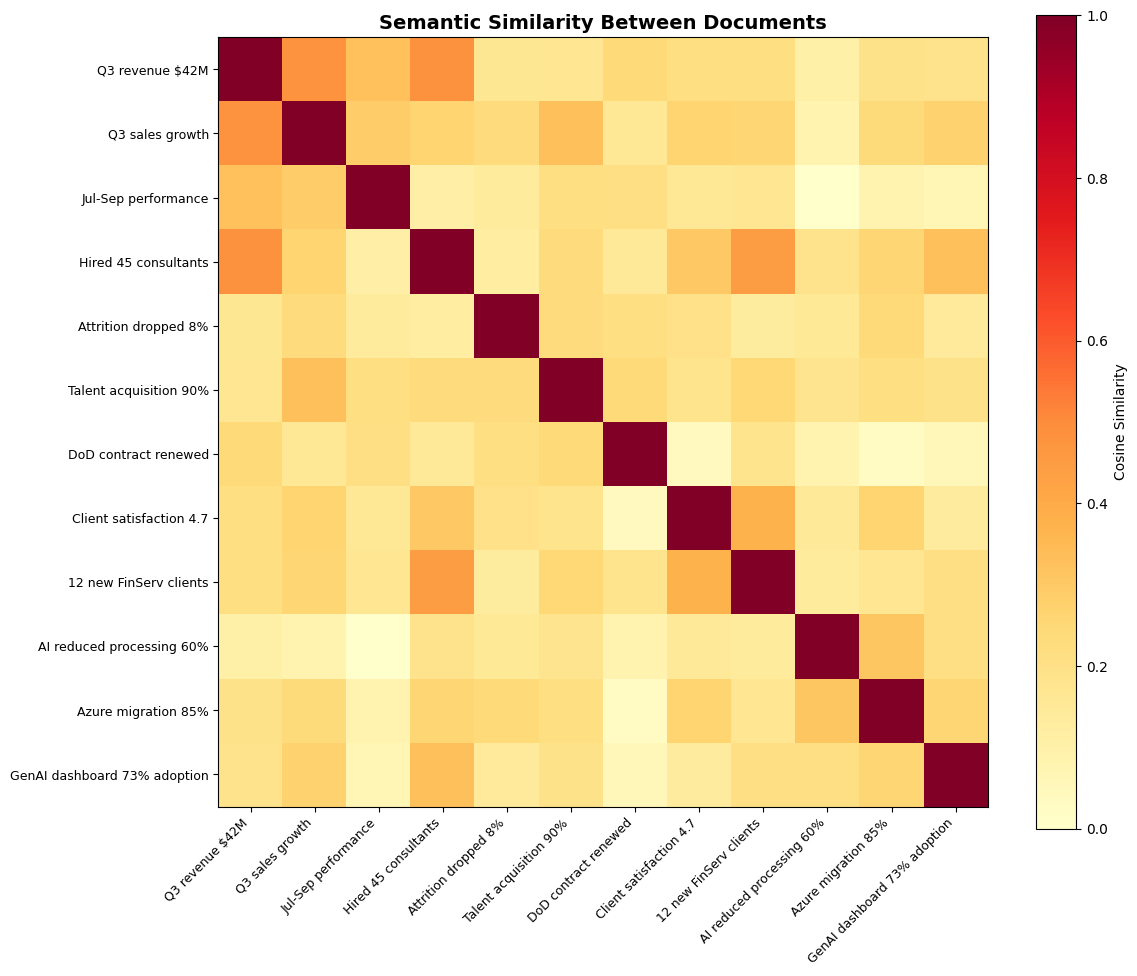


🔍 Notice how the model groups related concepts:
  • Revenue/sales/financial performance → similar to each other
  • Hiring/attrition/talent → similar to each other
  • Revenue and hiring → NOT similar (different topics)


In [6]:
# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Short labels for readability
short_labels = [
    "Q3 revenue $42M",
    "Q3 sales growth",
    "Jul-Sep performance",
    "Hired 45 consultants",
    "Attrition dropped 8%",
    "Talent acquisition 90%",
    "DoD contract renewed",
    "Client satisfaction 4.7",
    "12 new FinServ clients",
    "AI reduced processing 60%",
    "Azure migration 85%",
    "GenAI dashboard 73% adoption",
]

im = ax.imshow(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
plt.colorbar(im, label='Cosine Similarity')
ax.set_title('Semantic Similarity Between Documents', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Notice how the model groups related concepts:")
print("  • Revenue/sales/financial performance → similar to each other")
print("  • Hiring/attrition/talent → similar to each other")
print("  • Revenue and hiring → NOT similar (different topics)")

## Step 4: Semantic Search in Action

Now the magic — let's search these documents using natural language queries.

Watch how semantic search finds relevant results even when the **exact words don't match**:

In [7]:
def semantic_search(query, documents, embeddings, model, top_k=3):
    """Search documents by meaning, not keywords."""
    # Embed the query
    query_embedding = model.encode([query])
    
    # Compute similarity between query and all documents
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Rank by similarity
    ranked_indices = np.argsort(similarities)[::-1][:top_k]
    
    print(f"🔎 Query: \"{query}\"\n")
    print(f"{'Rank':<6} {'Similarity':<12} {'Document'}")
    print(f"{'-'*6} {'-'*12} {'-'*60}")
    
    for rank, idx in enumerate(ranked_indices, 1):
        print(f"{rank:<6} {similarities[idx]:<12.4f} {documents[idx]}")
    
    return ranked_indices, similarities


# Query 1: Different words, same meaning
print("=" * 80)
print("DEMO 1: The model understands meaning, not just keywords")
print("=" * 80)
semantic_search(
    "How much money did we make last quarter?",
    documents, embeddings, model
)
print("\n💡 Notice: The query says 'money' and 'last quarter'")
print("   but the top results mention 'revenue', 'sales', and 'Q3'.")
print("   Keyword search would have found ZERO results.")

DEMO 1: The model understands meaning, not just keywords
🔎 Query: "How much money did we make last quarter?"

Rank   Similarity   Document
------ ------------ ------------------------------------------------------------
1      0.4551       Q3 revenue reached $42 million, a 12% increase year-over-year.
2      0.3164       The talent acquisition team filled 90% of open positions within 30 days.
3      0.3130       Third quarter sales figures show strong growth across all practice areas.

💡 Notice: The query says 'money' and 'last quarter'
   but the top results mention 'revenue', 'sales', and 'Q3'.
   Keyword search would have found ZERO results.


In [8]:
# Query 2: Conceptual search
print("=" * 80)
print("DEMO 2: Searching by concept, not exact phrases")
print("=" * 80)
semantic_search(
    "Are people leaving the company?",
    documents, embeddings, model
)
print("\n💡 'People leaving' → finds 'attrition rate' and 'talent acquisition'")
print("   The model understands these are conceptually related.")

DEMO 2: Searching by concept, not exact phrases
🔎 Query: "Are people leaving the company?"

Rank   Similarity   Document
------ ------------ ------------------------------------------------------------
1      0.3644       Employee attrition rate dropped to 8% this quarter.
2      0.2597       We onboarded 12 new clients in the financial services sector.
3      0.2429       The talent acquisition team filled 90% of open positions within 30 days.

💡 'People leaving' → finds 'attrition rate' and 'talent acquisition'
   The model understands these are conceptually related.


In [9]:
# Query 3: Cross-domain understanding
print("=" * 80)
print("DEMO 3: Understanding domain context")
print("=" * 80)
semantic_search(
    "What's happening with our technology modernization?",
    documents, embeddings, model
)
print("\n💡 'Technology modernization' → finds Azure migration, AI platform,")
print("   and GenAI dashboard — all related to tech transformation.")

DEMO 3: Understanding domain context
🔎 Query: "What's happening with our technology modernization?"

Rank   Similarity   Document
------ ------------ ------------------------------------------------------------
1      0.2453       The new GenAI dashboard is now used by 73% of senior leadership.
2      0.2275       The AI platform deployment reduced document processing time by 60%.
3      0.2266       Third quarter sales figures show strong growth across all practice areas.

💡 'Technology modernization' → finds Azure migration, AI platform,
   and GenAI dashboard — all related to tech transformation.


In [10]:
# Query 4: Keyword search comparison
print("=" * 80)
print("DEMO 4: Semantic search vs keyword search")
print("=" * 80)

query = "government contract status"

print(f"\n📝 KEYWORD SEARCH for: \"{query}\"")
keyword_results = [doc for doc in documents if any(word in doc.lower() for word in query.lower().split())]
if keyword_results:
    for doc in keyword_results:
        print(f"   ✓ {doc}")
else:
    print("   ✗ No results found (none of these exact words appear in documents)")

print(f"\n🔎 SEMANTIC SEARCH for: \"{query}\"")
semantic_search(query, documents, embeddings, model)
print("\n💡 Keyword search found nothing. Semantic search found the DoD contract")
print("   because it understands 'government contract' ≈ 'DoD contract'.")

DEMO 4: Semantic search vs keyword search

📝 KEYWORD SEARCH for: "government contract status"
   ✓ The defense contract with the DoD was renewed for three additional years.

🔎 SEMANTIC SEARCH for: "government contract status"
🔎 Query: "government contract status"

Rank   Similarity   Document
------ ------------ ------------------------------------------------------------
1      0.3376       The defense contract with the DoD was renewed for three additional years.
2      0.1512       Employee attrition rate dropped to 8% this quarter.
3      0.1117       The financial performance in July through September exceeded expectations.

💡 Keyword search found nothing. Semantic search found the DoD contract
   because it understands 'government contract' ≈ 'DoD contract'.


## Step 5: Visualize the Embedding Space

Embeddings live in 384-dimensional space — impossible to visualize directly.
We'll use **t-SNE** to project them down to 2D while preserving relative distances.

Documents about similar topics should cluster together:

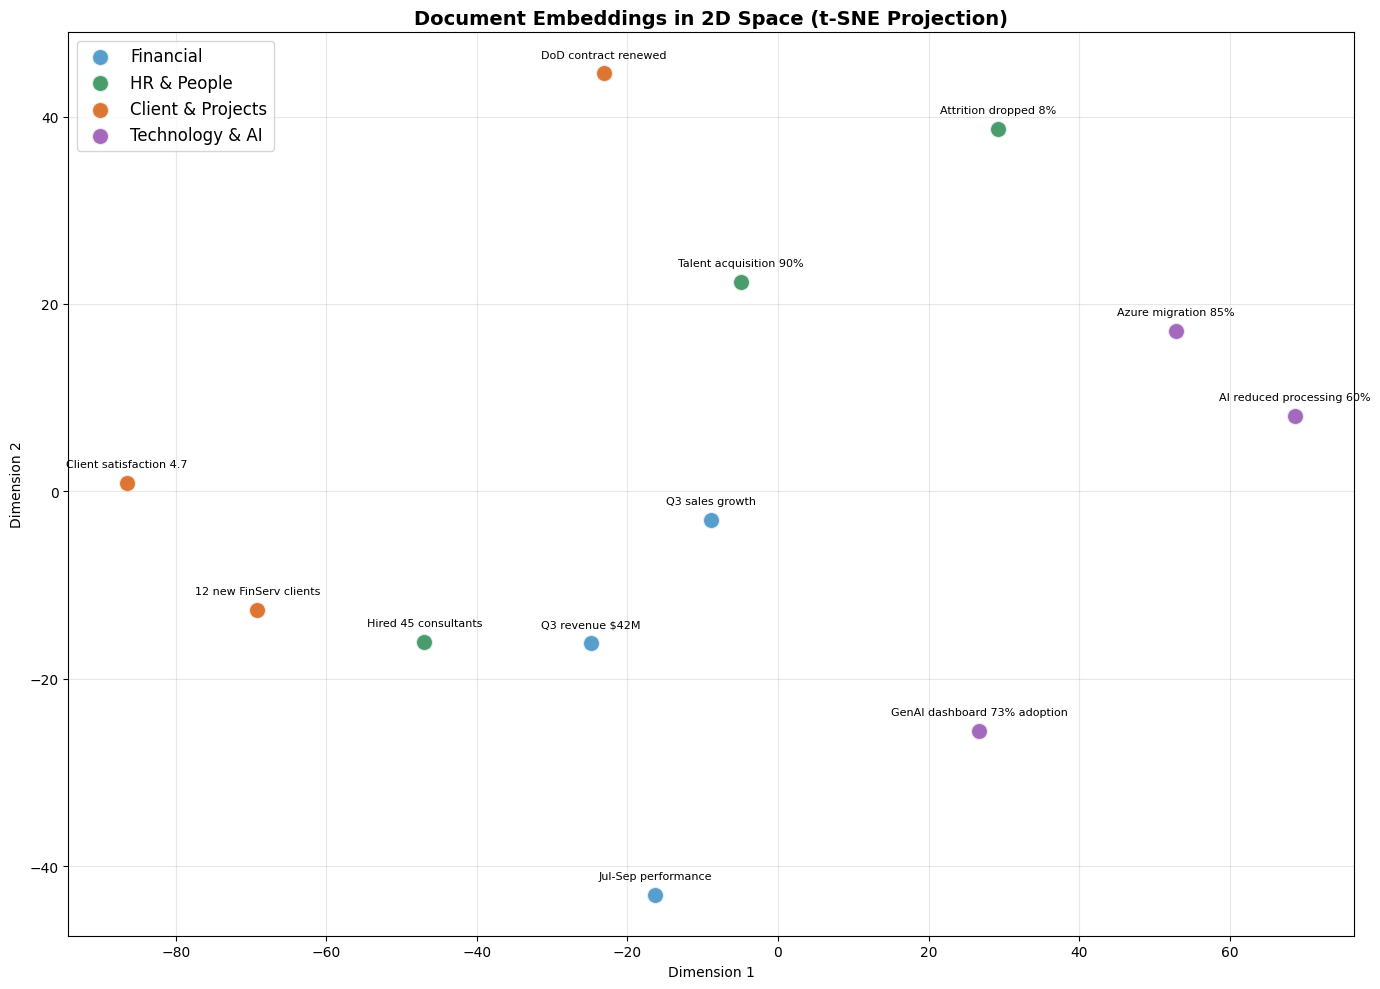


🎯 Key Insight: Documents about similar topics cluster together.
   This is how vector databases find relevant results — by finding
   the nearest neighbors in this high-dimensional space.

   In the real RAG pipeline, your user's query gets embedded into
   this same space, and the system finds the closest document vectors.


In [11]:
# Define categories for coloring
categories = [
    'Financial', 'Financial', 'Financial',
    'HR & People', 'HR & People', 'HR & People',
    'Client & Projects', 'Client & Projects', 'Client & Projects',
    'Technology & AI', 'Technology & AI', 'Technology & AI',
]

category_colors = {
    'Financial': '#2E86C1',
    'HR & People': '#1E8449',
    'Client & Projects': '#D35400',
    'Technology & AI': '#8E44AD',
}

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=4)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

for category in category_colors:
    mask = [c == category for c in categories]
    indices = [i for i, m in enumerate(mask) if m]
    ax.scatter(
        embeddings_2d[indices, 0],
        embeddings_2d[indices, 1],
        c=category_colors[category],
        label=category,
        s=150,
        alpha=0.8,
        edgecolors='white',
        linewidth=1.5,
    )

# Add labels
for i, label in enumerate(short_labels):
    ax.annotate(
        label,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=8,
        ha='center',
        va='bottom',
        xytext=(0, 10),
        textcoords='offset points',
    )

ax.legend(fontsize=12, loc='upper left')
ax.set_title('Document Embeddings in 2D Space (t-SNE Projection)', fontsize=14, fontweight='bold')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎯 Key Insight: Documents about similar topics cluster together.")
print("   This is how vector databases find relevant results — by finding")
print("   the nearest neighbors in this high-dimensional space.")
print("\n   In the real RAG pipeline, your user's query gets embedded into")
print("   this same space, and the system finds the closest document vectors.")

## Step 6: Build a Mini Vector Database

Let's simulate what a vector database does — store embeddings and retrieve the most similar ones for any query:

In [12]:
class SimpleVectorDB:
    """A minimal vector database to illustrate the concept."""
    
    def __init__(self, model):
        self.model = model
        self.documents = []
        self.embeddings = None
        self.metadata = []
    
    def add_documents(self, docs, metadata=None):
        """Add documents to the database."""
        self.documents.extend(docs)
        new_embeddings = self.model.encode(docs)
        
        if self.embeddings is None:
            self.embeddings = new_embeddings
        else:
            self.embeddings = np.vstack([self.embeddings, new_embeddings])
        
        if metadata:
            self.metadata.extend(metadata)
        else:
            self.metadata.extend([{}] * len(docs))
        
        print(f"✓ Added {len(docs)} documents. Total: {len(self.documents)}")
    
    def search(self, query, top_k=3):
        """Search by semantic similarity."""
        query_embedding = self.model.encode([query])
        similarities = cosine_similarity(query_embedding, self.embeddings)[0]
        ranked = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in ranked:
            results.append({
                'document': self.documents[idx],
                'similarity': round(float(similarities[idx]), 4),
                'metadata': self.metadata[idx],
            })
        return results


# Create our mini vector DB
db = SimpleVectorDB(model)

# Add documents with metadata (like you would in a real system)
db.add_documents(
    documents,
    metadata=[
        {'category': 'financial', 'quarter': 'Q3'},
        {'category': 'financial', 'quarter': 'Q3'},
        {'category': 'financial', 'quarter': 'Q3'},
        {'category': 'hr', 'quarter': 'Q3'},
        {'category': 'hr', 'quarter': 'Q3'},
        {'category': 'hr', 'quarter': 'Q3'},
        {'category': 'clients', 'quarter': 'Q3'},
        {'category': 'clients', 'quarter': 'Q3'},
        {'category': 'clients', 'quarter': 'Q3'},
        {'category': 'technology', 'quarter': 'Q3'},
        {'category': 'technology', 'quarter': 'Q3'},
        {'category': 'technology', 'quarter': 'Q3'},
    ]
)

✓ Added 12 documents. Total: 12


In [13]:
# Search our vector DB
query = "How is our workforce doing?"
results = db.search(query, top_k=3)

print(f"🔎 Query: \"{query}\"\n")
for i, result in enumerate(results, 1):
    print(f"  {i}. [{result['similarity']}] {result['document']}")
    print(f"     Category: {result['metadata'].get('category', 'N/A')}\n")

print("\n✅ This is exactly what happens inside ChromaDB, Pinecone, or Azure AI Search.")
print("   The difference is they optimize for billions of vectors with millisecond latency.")

🔎 Query: "How is our workforce doing?"

  1. [0.3411] Third quarter sales figures show strong growth across all practice areas.
     Category: financial

  2. [0.2405] We onboarded 12 new clients in the financial services sector.
     Category: clients

  3. [0.2352] We hired 45 new consultants in Q3, bringing total headcount to 850.
     Category: hr


✅ This is exactly what happens inside ChromaDB, Pinecone, or Azure AI Search.
   The difference is they optimize for billions of vectors with millisecond latency.


## Step 7: Simulating the Full RAG Flow

Now let's put it all together — a simplified RAG pipeline that:
1. Takes a user question
2. Retrieves relevant context from our vector DB
3. Builds an augmented prompt
4. Shows what would be sent to the LLM

(We won't call an actual LLM here — just show the assembled context)

In [14]:
def simulate_rag(query, db, top_k=3):
    """Simulate the RAG pipeline — retrieve context and build the augmented prompt."""
    
    # Step 1: Retrieve relevant documents
    results = db.search(query, top_k=top_k)
    
    # Step 2: Build the context from retrieved documents
    context = "\n".join([f"- {r['document']}" for r in results])
    
    # Step 3: Assemble the augmented prompt
    system_prompt = """You are a senior financial analyst at Guidehouse.
Answer the user's question based ONLY on the provided context.
If the context doesn't contain the answer, say "I don't have that data."
Always cite which data point supports your answer."""
    
    augmented_prompt = f"""SYSTEM: {system_prompt}

CONTEXT (retrieved from company data):
{context}

USER QUESTION: {query}

ANSWER:"""
    
    # Display the full pipeline
    print("=" * 80)
    print("                    RAG PIPELINE SIMULATION")
    print("=" * 80)
    
    print(f"\n📥 USER QUERY: \"{query}\"")
    
    print(f"\n🔍 RETRIEVAL (top {top_k} results from vector DB):")
    for i, r in enumerate(results, 1):
        print(f"   {i}. [{r['similarity']}] {r['document']}")
    
    print(f"\n📋 ASSEMBLED PROMPT (this is what the LLM would receive):")
    print("-" * 60)
    print(augmented_prompt)
    print("-" * 60)
    
    print(f"\n💡 KEY INSIGHT:")
    print(f"   The LLM never saw our company data during training.")
    print(f"   RAG injected {len(results)} relevant data points into the prompt.")
    print(f"   The model can now answer accurately because the data is RIGHT THERE.")
    print(f"   This is NOT training. The model's weights never changed.")
    
    return augmented_prompt


# Run it!
simulate_rag("What's our revenue performance this quarter?", db)

                    RAG PIPELINE SIMULATION

📥 USER QUERY: "What's our revenue performance this quarter?"

🔍 RETRIEVAL (top 3 results from vector DB):
   1. [0.4777] Third quarter sales figures show strong growth across all practice areas.
   2. [0.4656] Q3 revenue reached $42 million, a 12% increase year-over-year.
   3. [0.3933] The financial performance in July through September exceeded expectations.

📋 ASSEMBLED PROMPT (this is what the LLM would receive):
------------------------------------------------------------
SYSTEM: You are a senior financial analyst at Guidehouse.
Answer the user's question based ONLY on the provided context.
If the context doesn't contain the answer, say "I don't have that data."
Always cite which data point supports your answer.

CONTEXT (retrieved from company data):
- Third quarter sales figures show strong growth across all practice areas.
- Q3 revenue reached $42 million, a 12% increase year-over-year.
- The financial performance in July through Sep

'SYSTEM: You are a senior financial analyst at Guidehouse.\nAnswer the user\'s question based ONLY on the provided context.\nIf the context doesn\'t contain the answer, say "I don\'t have that data."\nAlways cite which data point supports your answer.\n\nCONTEXT (retrieved from company data):\n- Third quarter sales figures show strong growth across all practice areas.\n- Q3 revenue reached $42 million, a 12% increase year-over-year.\n- The financial performance in July through September exceeded expectations.\n\nUSER QUESTION: What\'s our revenue performance this quarter?\n\nANSWER:'

In [15]:
# Try another query
simulate_rag("Are we having trouble keeping employees?", db)

                    RAG PIPELINE SIMULATION

📥 USER QUERY: "Are we having trouble keeping employees?"

🔍 RETRIEVAL (top 3 results from vector DB):
   1. [0.2842] Employee attrition rate dropped to 8% this quarter.
   2. [0.1865] We onboarded 12 new clients in the financial services sector.
   3. [0.1764] The talent acquisition team filled 90% of open positions within 30 days.

📋 ASSEMBLED PROMPT (this is what the LLM would receive):
------------------------------------------------------------
SYSTEM: You are a senior financial analyst at Guidehouse.
Answer the user's question based ONLY on the provided context.
If the context doesn't contain the answer, say "I don't have that data."
Always cite which data point supports your answer.

CONTEXT (retrieved from company data):
- Employee attrition rate dropped to 8% this quarter.
- We onboarded 12 new clients in the financial services sector.
- The talent acquisition team filled 90% of open positions within 30 days.

USER QUESTION: Are we h

'SYSTEM: You are a senior financial analyst at Guidehouse.\nAnswer the user\'s question based ONLY on the provided context.\nIf the context doesn\'t contain the answer, say "I don\'t have that data."\nAlways cite which data point supports your answer.\n\nCONTEXT (retrieved from company data):\n- Employee attrition rate dropped to 8% this quarter.\n- We onboarded 12 new clients in the financial services sector.\n- The talent acquisition team filled 90% of open positions within 30 days.\n\nUSER QUESTION: Are we having trouble keeping employees?\n\nANSWER:'

## Key Takeaways

1. **Embeddings capture meaning, not words.** "How much money did we make" and "Q3 revenue" produce similar vectors because they mean the same thing.

2. **Semantic search beats keyword search** for natural language questions — which is exactly how executives ask questions in a dashboard.

3. **RAG is NOT training.** The model's weights never change. We simply retrieve relevant data and include it in the prompt. Think of it as giving the model a cheat sheet for each question.

4. **Vector databases are specialized for this.** Our `SimpleVectorDB` works for 12 documents. Production systems (ChromaDB, Pinecone, Azure AI Search) handle millions of vectors with millisecond latency.

5. **The quality of RAG depends on the quality of the pipeline.** Chunking strategy, embedding model choice, and retrieval parameters all affect what the model sees — and therefore what it says.

---

### Next Steps

- **[02-build-a-rag-pipeline.ipynb](02-build-a-rag-pipeline.ipynb)** — Build a full RAG system with a real vector database and LLM
- **[03-chunking-strategies.ipynb](03-chunking-strategies.ipynb)** — Experiment with different chunking approaches and see how they affect retrieval
- **[04-embeddings-explorer.ipynb](04-embeddings-explorer.ipynb)** — Interactive 3D visualization of embedding space